### Round 1 Analysis - INTARIAN_PEPPER_ROOT

In [1]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

import prosperity4
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)


plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [2]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round1" / "data"
ROUND_NUM = 1
DAYS = [-2, -1, 0]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (60000, 17)
Trades Shape : (2276, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,-2
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,-2


### Splitting the datasets based on the products

In [3]:
products = prices_df["product"].unique()

pepper_prices_df = prices_df[prices_df["product"] == "INTARIAN_PEPPER_ROOT"]
pepper_trades_df = trades_df[trades_df["symbol"] == "INTARIAN_PEPPER_ROOT"]

In [4]:
'''
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
'''

pepper_trades = pepper_trades_df.copy()

# Grouping and merging the EMERALDS so we only have 1 dataset containing both prices and trades, sorted by timestamp
pepper_trades = pepper_trades.drop(columns = ["buyer", "seller", "currency"])
pepper_trades = pepper_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
pepper_trades = pepper_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
pepper = pepper_prices_df.merge(pepper_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
pepper = convert_timestamp(pepper)

pepper.head()


,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t
0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,NaN,NaN,-3000000
1,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,NaN,NaN,-2999900
2,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,NaN,NaN,-2999800
3,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0,NaN,NaN,-2999700
4,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0,NaN,NaN,-2999600


# Price and Trades plots

C:\Users\marco\AppData\Local\Temp\ipykernel_33868\1618422473.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


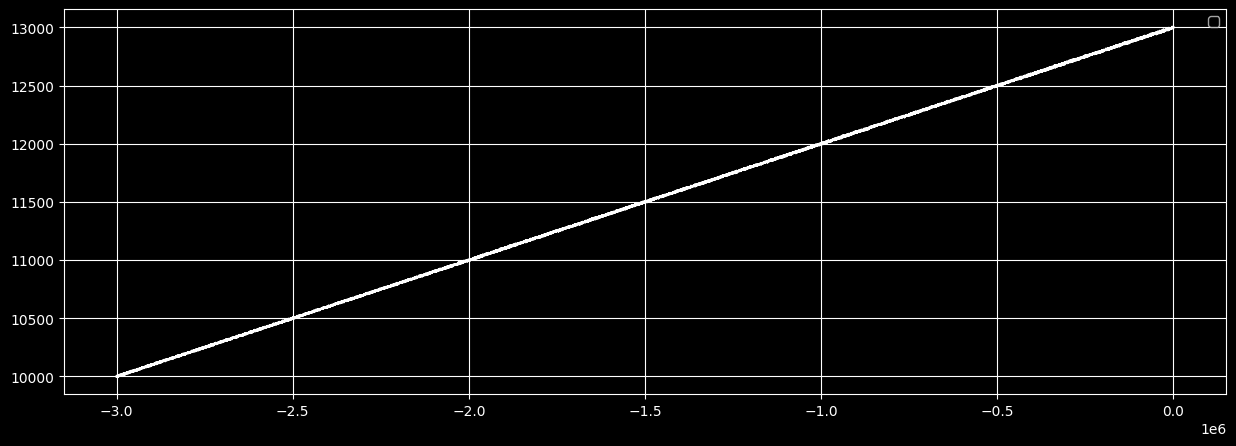

In [5]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(pepper["t"], pepper["mid_price"].replace(0, np.nan), color = "white")
plt.grid(True)
plt.legend()
plt.show()

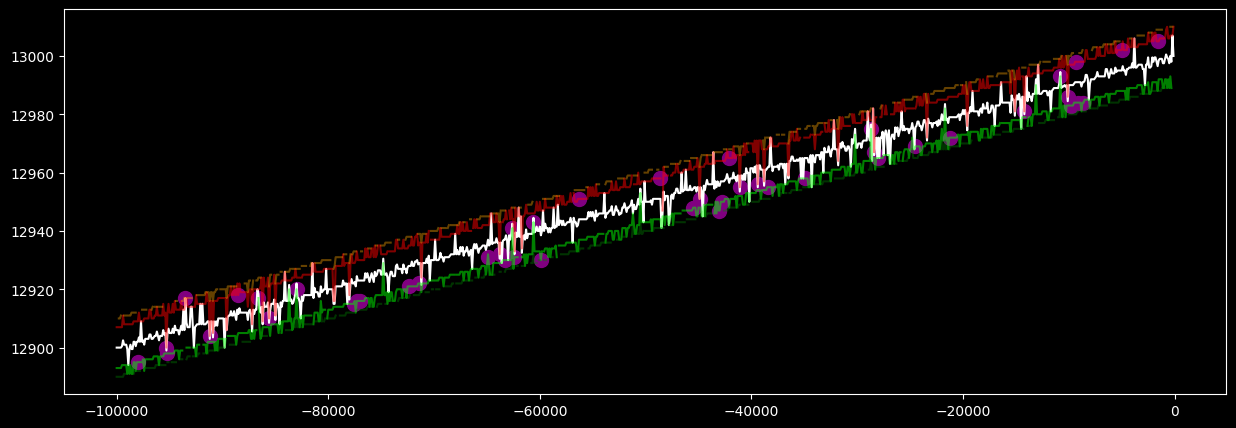

In [6]:
# This considers the mid price
plt.figure(figsize=(15,5))
plt.plot(pepper["t"][-1000:], pepper["mid_price"][-1000:].replace(0, np.nan), color = "white", alpha = 1)
plt.plot(pepper["t"][-1000:], pepper["ask_price_1"][-1000:].replace(0, np.nan), color = "red", alpha = 0.5)
plt.plot(pepper["t"][-1000:], pepper["ask_price_2"][-1000:].replace(0, np.nan), color = "orange", alpha = 0.4)
plt.plot(pepper["t"][-1000:], pepper["ask_price_3"][-1000:].replace(0, np.nan), color = "salmon", alpha = 0.3)
plt.plot(pepper["t"][-1000:], pepper["bid_price_1"][-1000:].replace(0, np.nan), color = "lime", alpha = 0.5)
plt.plot(pepper["t"][-1000:], pepper["bid_price_2"][-1000:].replace(0, np.nan), color = "green", alpha = 0.4)
plt.plot(pepper["t"][-1000:], pepper["bid_price_3"][-1000:].replace(0, np.nan), color = "darkgreen", alpha = 0.4)
plt.scatter(pepper["t"][-1000:], pepper["market order price"][-1000:].replace(0, np.nan), color = "purple", alpha = 1, s = 100)
plt.show()